# Complex Computing Project (CCP): Neural Computing System for MNIST

**Course:** Artificial Neural Network (BSAI F23 Red/Blue)  **Students:** Ali Hamza (B23F0063AI106) & Zarmeena Jawad (B23F0115AI125)  **Section:** B.S AI Red  **Instructor:** Dr. Abid Ali  **Due date:** 25-04-2026 (MS Teams)

> **Rule:** Dataset loading may use TensorFlow/Keras or TorchVision, but **all models are implemented from scratch using NumPy only**.



In [1]:
# Setup (self-contained for Cursor + Colab extension)
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')

# If `src/` is missing (common when only the notebook is synced), recreate it from embedded sources.
_EMBEDDED = {
    'src/__init__.py': '"""\nCCP Artificial Neural Network - NumPy-from-scratch implementations.\n\nModules:\n- data: MNIST loading + preprocessing\n- perceptron: binary perceptron\n- adaline: Adaline via delta rule (batch GD)\n- som: Kohonen SOM\n- mlp: multi-layer perceptron (backprop)\n"""\n\n',
    'src/utils.py': 'from __future__ import annotations\n\nfrom dataclasses import dataclass\n\nimport numpy as np\n\n\ndef set_seed(seed: int = 42) -> None:\n    np.random.seed(seed)\n\n\ndef one_hot(y: np.ndarray, num_classes: int) -> np.ndarray:\n    y = np.asarray(y).astype(int)\n    out = np.zeros((y.shape[0], num_classes), dtype=np.float32)\n    out[np.arange(y.shape[0]), y] = 1.0\n    return out\n\n\n@dataclass(frozen=True)\nclass Standardizer:\n    mean_: np.ndarray\n    std_: np.ndarray\n\n    def transform(self, x: np.ndarray) -> np.ndarray:\n        return (x - self.mean_) / (self.std_ + 1e-8)\n\n    @staticmethod\n    def fit(x: np.ndarray) -> "Standardizer":\n        mean_ = x.mean(axis=0, keepdims=True)\n        std_ = x.std(axis=0, keepdims=True)\n        return Standardizer(mean_=mean_, std_=std_)\n\n\ndef train_val_split(\n    x: np.ndarray,\n    y: np.ndarray,\n    val_ratio: float = 0.1,\n    seed: int = 42,\n) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:\n    rng = np.random.default_rng(seed)\n    idx = np.arange(x.shape[0])\n    rng.shuffle(idx)\n    split = int(x.shape[0] * (1.0 - val_ratio))\n    train_idx, val_idx = idx[:split], idx[split:]\n    return x[train_idx], y[train_idx], x[val_idx], y[val_idx]\n\n\ndef minibatches(\n    x: np.ndarray,\n    y: np.ndarray,\n    batch_size: int,\n    shuffle: bool = True,\n    seed: int | None = None,\n):\n    n = x.shape[0]\n    idx = np.arange(n)\n    if shuffle:\n        rng = np.random.default_rng(seed)\n        rng.shuffle(idx)\n    for start in range(0, n, batch_size):\n        batch_idx = idx[start : start + batch_size]\n        yield x[batch_idx], y[batch_idx]\n\n\ndef pca_2d(x: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:\n    """\n    Simple PCA (NumPy SVD) returning 2D projection.\n    Returns (x2, components, mean).\n    """\n    x = np.asarray(x, dtype=np.float32)\n    mean = x.mean(axis=0, keepdims=True)\n    xc = x - mean\n    # SVD on covariance-equivalent: right singular vectors of centered data\n    _, _, vt = np.linalg.svd(xc, full_matrices=False)\n    components = vt[:2]  # (2, D)\n    x2 = xc @ components.T\n    return x2, components, mean\n\n\ndef apply_pca(x: np.ndarray, components: np.ndarray, mean: np.ndarray) -> np.ndarray:\n    x = np.asarray(x, dtype=np.float32)\n    return (x - mean) @ components.T\n\n',
    'src/data.py': 'from __future__ import annotations\n\nimport numpy as np\n\nfrom .utils import Standardizer, train_val_split\n\n\ndef load_mnist(flatten: bool = True) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:\n    """\n    Loads MNIST using TensorFlow/Keras (allowed for loading only).\n    Returns float32 images scaled to [0, 1].\n    """\n    try:\n        from tensorflow.keras.datasets import mnist  # type: ignore\n    except Exception as exc:  # pragma: no cover\n        raise RuntimeError(\n            "TensorFlow is required only to *load* MNIST in Colab. "\n            "In Google Colab it is preinstalled."\n        ) from exc\n\n    (x_train, y_train), (x_test, y_test) = mnist.load_data()\n    x_train = x_train.astype(np.float32) / 255.0\n    x_test = x_test.astype(np.float32) / 255.0\n\n    if flatten:\n        x_train = x_train.reshape(x_train.shape[0], -1)\n        x_test = x_test.reshape(x_test.shape[0], -1)\n\n    return x_train, y_train.astype(int), x_test, y_test.astype(int)\n\n\ndef mnist_binary_subset(\n    x: np.ndarray,\n    y: np.ndarray,\n    digit_a: int,\n    digit_b: int,\n    max_samples: int | None = None,\n) -> tuple[np.ndarray, np.ndarray]:\n    mask = (y == digit_a) | (y == digit_b)\n    x_sub = x[mask]\n    y_sub = y[mask]\n    y_bin = (y_sub == digit_b).astype(int)  # digit_a -> 0, digit_b -> 1\n    if max_samples is not None and x_sub.shape[0] > max_samples:\n        x_sub = x_sub[:max_samples]\n        y_bin = y_bin[:max_samples]\n    return x_sub.astype(np.float32), y_bin.astype(int)\n\n\ndef standardize_train_test(\n    x_train: np.ndarray, x_test: np.ndarray\n) -> tuple[np.ndarray, np.ndarray, Standardizer]:\n    scaler = Standardizer.fit(x_train)\n    return scaler.transform(x_train).astype(np.float32), scaler.transform(x_test).astype(np.float32), scaler\n\n\ndef make_mnist_splits(\n    val_ratio: float = 0.1,\n    standardize: bool = True,\n    seed: int = 42,\n) -> dict[str, np.ndarray]:\n    x_train, y_train, x_test, y_test = load_mnist(flatten=True)\n    x_tr, y_tr, x_val, y_val = train_val_split(x_train, y_train, val_ratio=val_ratio, seed=seed)\n\n    if standardize:\n        x_tr_s, x_val_s, scaler = standardize_train_test(x_tr, x_val)\n        x_test_s = scaler.transform(x_test).astype(np.float32)\n        return {\n            "x_train": x_tr_s,\n            "y_train": y_tr,\n            "x_val": x_val_s,\n            "y_val": y_val,\n            "x_test": x_test_s,\n            "y_test": y_test,\n        }\n\n    return {\n        "x_train": x_tr.astype(np.float32),\n        "y_train": y_tr,\n        "x_val": x_val.astype(np.float32),\n        "y_val": y_val,\n        "x_test": x_test.astype(np.float32),\n        "y_test": y_test,\n    }\n\n',
    'src/metrics.py': 'from __future__ import annotations\n\nimport numpy as np\n\n\ndef accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:\n    y_true = np.asarray(y_true).astype(int)\n    y_pred = np.asarray(y_pred).astype(int)\n    return float((y_true == y_pred).mean())\n\n\ndef confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:\n    y_true = np.asarray(y_true).astype(int)\n    y_pred = np.asarray(y_pred).astype(int)\n    cm = np.zeros((num_classes, num_classes), dtype=np.int64)\n    for t, p in zip(y_true, y_pred):\n        cm[t, p] += 1\n    return cm\n\n\ndef precision_recall_f1(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:\n    y_true = np.asarray(y_true).astype(int)\n    y_pred = np.asarray(y_pred).astype(int)\n    tp = int(((y_true == 1) & (y_pred == 1)).sum())\n    fp = int(((y_true == 0) & (y_pred == 1)).sum())\n    fn = int(((y_true == 1) & (y_pred == 0)).sum())\n    precision = tp / (tp + fp + 1e-12)\n    recall = tp / (tp + fn + 1e-12)\n    f1 = 2 * precision * recall / (precision + recall + 1e-12)\n    return float(precision), float(recall), float(f1)\n\n',
    'src/plots.py': 'from __future__ import annotations\n\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n\ndef savefig(path: str, dpi: int = 160) -> None:\n    plt.tight_layout()\n    plt.savefig(path, dpi=dpi, bbox_inches="tight")\n\n\ndef plot_decision_boundary_2d(\n    x2: np.ndarray,\n    y: np.ndarray,\n    w: np.ndarray,\n    title: str,\n    path: str | None = None,\n) -> None:\n    """\n    x2: (N,2) features, w: (3,) bias + 2 weights for boundary: w0 + w1*x + w2*y = 0\n    """\n    x2 = np.asarray(x2)\n    y = np.asarray(y)\n\n    plt.figure(figsize=(6, 5))\n    plt.scatter(x2[:, 0], x2[:, 1], c=y, s=8, cmap="coolwarm", alpha=0.85)\n\n    x_min, x_max = x2[:, 0].min() - 0.5, x2[:, 0].max() + 0.5\n    xs = np.linspace(x_min, x_max, 200)\n    if abs(w[2]) < 1e-12:\n        ys = np.zeros_like(xs)\n    else:\n        ys = -(w[0] + w[1] * xs) / w[2]\n    plt.plot(xs, ys, "k-", lw=2)\n    plt.title(title)\n    plt.xlabel("PC1")\n    plt.ylabel("PC2")\n    if path is not None:\n        savefig(path)\n\n\ndef plot_curves(history: dict[str, list[float]], title: str, path: str | None = None) -> None:\n    plt.figure(figsize=(7, 4))\n    for k, v in history.items():\n        plt.plot(v, label=k)\n    plt.title(title)\n    plt.xlabel("Epoch")\n    plt.legend()\n    if path is not None:\n        savefig(path)\n\n\ndef plot_confusion_matrix(cm: np.ndarray, title: str, path: str | None = None) -> None:\n    plt.figure(figsize=(6, 5))\n    plt.imshow(cm, interpolation="nearest", cmap="Blues")\n    plt.title(title)\n    plt.colorbar()\n    plt.xlabel("Predicted")\n    plt.ylabel("True")\n    if path is not None:\n        savefig(path)\n\n\ndef plot_activation_curves(path: str | None = None) -> None:\n    xs = np.linspace(-5, 5, 600)\n    sigmoid = 1.0 / (1.0 + np.exp(-xs))\n    tanh = np.tanh(xs)\n    relu = np.maximum(0, xs)\n    dsigmoid = sigmoid * (1 - sigmoid)\n    dtanh = 1 - tanh**2\n    drelu = (xs > 0).astype(float)\n\n    plt.figure(figsize=(10, 4))\n    plt.subplot(1, 2, 1)\n    plt.plot(xs, sigmoid, label="Sigmoid")\n    plt.plot(xs, tanh, label="Tanh")\n    plt.plot(xs, relu, label="ReLU")\n    plt.title("Activations")\n    plt.legend()\n    plt.grid(True, alpha=0.25)\n\n    plt.subplot(1, 2, 2)\n    plt.plot(xs, dsigmoid, label="Sigmoid\'")\n    plt.plot(xs, dtanh, label="Tanh\'")\n    plt.plot(xs, drelu, label="ReLU\'")\n    plt.title("Gradients")\n    plt.legend()\n    plt.grid(True, alpha=0.25)\n\n    if path is not None:\n        savefig(path)\n\n',
    'src/perceptron.py': 'from __future__ import annotations\n\nimport numpy as np\n\n\nclass Perceptron:\n    """\n    Binary perceptron with step activation.\n    Uses labels y in {0,1}.\n    """\n\n    def __init__(self, lr: float = 0.01, epochs: int = 25, seed: int = 42):\n        self.lr = float(lr)\n        self.epochs = int(epochs)\n        self.seed = int(seed)\n        self.w: np.ndarray | None = None\n        self.history_: dict[str, list] = {"miscls": [], "w": []}\n\n    @staticmethod\n    def _add_bias(x: np.ndarray) -> np.ndarray:\n        return np.concatenate([np.ones((x.shape[0], 1), dtype=x.dtype), x], axis=1)\n\n    def predict(self, x: np.ndarray) -> np.ndarray:\n        if self.w is None:\n            raise RuntimeError("Model not fitted.")\n        xb = self._add_bias(np.asarray(x, dtype=np.float32))\n        y_hat = (xb @ self.w >= 0).astype(int)\n        return y_hat\n\n    def fit(self, x: np.ndarray, y: np.ndarray) -> "Perceptron":\n        x = np.asarray(x, dtype=np.float32)\n        y = np.asarray(y).astype(int)\n        xb = self._add_bias(x)\n\n        rng = np.random.default_rng(self.seed)\n        self.w = rng.normal(0, 0.01, size=(xb.shape[1],)).astype(np.float32)\n\n        for _ in range(self.epochs):\n            miscls = 0\n            for xi, di in zip(xb, y):\n                yi = 1 if (xi @ self.w) >= 0 else 0\n                err = di - yi\n                if err != 0:\n                    miscls += 1\n                    self.w = self.w + self.lr * err * xi\n            self.history_["miscls"].append(int(miscls))\n            self.history_["w"].append(self.w.copy())\n        return self\n\n',
    'src/adaline.py': 'from __future__ import annotations\n\nimport numpy as np\n\n\nclass AdalineGD:\n    """\n    Adaline trained with batch gradient descent on MSE using continuous linear output.\n    Labels can be {0,1} (internally used as floats).\n    """\n\n    def __init__(self, lr: float = 0.001, epochs: int = 50, seed: int = 42):\n        self.lr = float(lr)\n        self.epochs = int(epochs)\n        self.seed = int(seed)\n        self.w: np.ndarray | None = None\n        self.history_: dict[str, list[float] | list[np.ndarray]] = {"mse": [], "w": []}\n\n    @staticmethod\n    def _add_bias(x: np.ndarray) -> np.ndarray:\n        return np.concatenate([np.ones((x.shape[0], 1), dtype=x.dtype), x], axis=1)\n\n    def net(self, x: np.ndarray) -> np.ndarray:\n        if self.w is None:\n            raise RuntimeError("Model not fitted.")\n        xb = self._add_bias(np.asarray(x, dtype=np.float32))\n        return xb @ self.w\n\n    def predict(self, x: np.ndarray, threshold: float = 0.0) -> np.ndarray:\n        y_lin = self.net(x)\n        return (y_lin >= threshold).astype(int)\n\n    def fit(self, x: np.ndarray, y: np.ndarray) -> "AdalineGD":\n        x = np.asarray(x, dtype=np.float32)\n        y = np.asarray(y, dtype=np.float32).reshape(-1)\n        xb = self._add_bias(x)\n\n        rng = np.random.default_rng(self.seed)\n        self.w = rng.normal(0, 0.01, size=(xb.shape[1],)).astype(np.float32)\n\n        n = xb.shape[0]\n        for _ in range(self.epochs):\n            y_hat = xb @ self.w\n            err = y - y_hat\n            grad = -(xb.T @ err) / n  # d/dw (1/2n * sum err^2) = -(X^T err)/n\n            self.w = self.w - self.lr * grad\n            mse = float((err**2).mean() / 2.0)\n            self.history_["mse"].append(mse)\n            self.history_["w"].append(self.w.copy())\n        return self\n\n\ndef mse_loss_surface(\n    x2: np.ndarray,\n    y: np.ndarray,\n    w0_range: tuple[float, float] = (-1.0, 1.0),\n    w1_range: tuple[float, float] = (-2.0, 2.0),\n    grid: int = 120,\n) -> tuple[np.ndarray, np.ndarray, np.ndarray]:\n    """\n    Computes MSE surface for 2D input with bias fixed at 0.\n    Returns (W0, W1, Z) where Z is 1/2 * mean((y - (w0*x1 + w1*x2))^2).\n    """\n    x2 = np.asarray(x2, dtype=np.float32)\n    y = np.asarray(y, dtype=np.float32).reshape(-1)\n    w0 = np.linspace(w0_range[0], w0_range[1], grid)\n    w1 = np.linspace(w1_range[0], w1_range[1], grid)\n    W0, W1 = np.meshgrid(w0, w1)\n    z = np.zeros_like(W0, dtype=np.float32)\n    x1 = x2[:, 0]\n    x2v = x2[:, 1]\n    for i in range(grid):\n        for j in range(grid):\n            y_hat = W0[i, j] * x1 + W1[i, j] * x2v\n            z[i, j] = 0.5 * np.mean((y - y_hat) ** 2)\n    return W0, W1, z\n\n',
    'src/som.py': 'from __future__ import annotations\n\nimport numpy as np\n\n\nclass SOM:\n    """\n    Kohonen Self-Organizing Map (2D grid) with Gaussian neighborhood and exponential decay.\n    """\n\n    def __init__(\n        self,\n        grid_h: int,\n        grid_w: int,\n        input_dim: int,\n        lr0: float = 0.5,\n        sigma0: float | None = None,\n        epochs: int = 10,\n        seed: int = 42,\n    ):\n        self.grid_h = int(grid_h)\n        self.grid_w = int(grid_w)\n        self.input_dim = int(input_dim)\n        self.lr0 = float(lr0)\n        self.sigma0 = float(sigma0) if sigma0 is not None else float(max(grid_h, grid_w) / 2.0)\n        self.epochs = int(epochs)\n        self.seed = int(seed)\n\n        self.weights: np.ndarray | None = None  # (H,W,D)\n        self._coords = np.stack(\n            np.meshgrid(np.arange(self.grid_h), np.arange(self.grid_w), indexing="ij"),\n            axis=-1,\n        ).astype(np.int32)  # (H,W,2)\n\n    def _init_weights(self, x: np.ndarray) -> None:\n        rng = np.random.default_rng(self.seed)\n        # sample from data distribution for faster convergence\n        idx = rng.integers(0, x.shape[0], size=(self.grid_h, self.grid_w))\n        self.weights = x[idx].astype(np.float32).copy()\n\n    def _decay(self, t: int, max_t: int) -> tuple[float, float]:\n        lam = max_t / np.log(self.sigma0 + 1e-12)\n        lr_t = self.lr0 * np.exp(-t / lam)\n        sigma_t = self.sigma0 * np.exp(-t / lam)\n        return float(lr_t), float(sigma_t)\n\n    def bmu(self, x: np.ndarray) -> tuple[int, int]:\n        if self.weights is None:\n            raise RuntimeError("SOM not fitted.")\n        w = self.weights.reshape(-1, self.input_dim)  # (H*W,D)\n        d = np.linalg.norm(w - x.reshape(1, -1), axis=1)\n        idx = int(np.argmin(d))\n        return idx // self.grid_w, idx % self.grid_w\n\n    def bmu_batch(self, x: np.ndarray) -> np.ndarray:\n        if self.weights is None:\n            raise RuntimeError("SOM not fitted.")\n        w = self.weights.reshape(-1, self.input_dim)  # (M,D)\n        # compute squared distances efficiently: ||a-b||^2 = ||a||^2 + ||b||^2 - 2a.b\n        x = x.astype(np.float32)\n        w2 = (w**2).sum(axis=1, keepdims=True)  # (M,1)\n        x2 = (x**2).sum(axis=1, keepdims=True).T  # (1,N)\n        dist2 = w2 + x2 - 2 * (w @ x.T)  # (M,N)\n        idx = dist2.argmin(axis=0)  # (N,)\n        rows = (idx // self.grid_w).astype(np.int32)\n        cols = (idx % self.grid_w).astype(np.int32)\n        return np.stack([rows, cols], axis=1)  # (N,2)\n\n    def fit(self, x: np.ndarray) -> "SOM":\n        x = np.asarray(x, dtype=np.float32)\n        if self.weights is None:\n            self._init_weights(x)\n        assert self.weights is not None\n\n        # NOTE: Full-grid updates per sample are extremely slow for MNIST.\n        # We update only a local neighborhood window (≈3σ radius) around the BMU.\n        max_t = self.epochs * x.shape[0]\n        t = 0\n        for _ in range(self.epochs):\n            # shuffle each epoch for robustness\n            idx = np.random.permutation(x.shape[0])\n            x_epoch = x[idx]\n            for xi in x_epoch:\n                bmu_r, bmu_c = self.bmu(xi)\n                lr_t, sigma_t = self._decay(t, max_t)\n\n                # Gaussian neighborhood over a local window\n                rad = int(np.ceil(3.0 * sigma_t))\n                r0 = max(0, bmu_r - rad)\n                r1 = min(self.grid_h - 1, bmu_r + rad)\n                c0 = max(0, bmu_c - rad)\n                c1 = min(self.grid_w - 1, bmu_c + rad)\n\n                coords = self._coords[r0 : r1 + 1, c0 : c1 + 1]\n                w_local = self.weights[r0 : r1 + 1, c0 : c1 + 1]\n\n                diff = coords - np.array([bmu_r, bmu_c], dtype=np.int32)\n                dist2 = (diff[..., 0] ** 2 + diff[..., 1] ** 2).astype(np.float32)\n                h = np.exp(-dist2 / (2.0 * (sigma_t**2 + 1e-12))).astype(np.float32)  # (h,w)\n\n                self.weights[r0 : r1 + 1, c0 : c1 + 1] = w_local + lr_t * h[..., None] * (xi - w_local)\n                t += 1\n        return self\n\n    def u_matrix(self) -> np.ndarray:\n        if self.weights is None:\n            raise RuntimeError("SOM not fitted.")\n        w = self.weights\n        umat = np.zeros((self.grid_h, self.grid_w), dtype=np.float32)\n        for r in range(self.grid_h):\n            for c in range(self.grid_w):\n                neigh = []\n                if r > 0:\n                    neigh.append(w[r - 1, c])\n                if r < self.grid_h - 1:\n                    neigh.append(w[r + 1, c])\n                if c > 0:\n                    neigh.append(w[r, c - 1])\n                if c < self.grid_w - 1:\n                    neigh.append(w[r, c + 1])\n                if neigh:\n                    neigh = np.stack(neigh, axis=0)\n                    umat[r, c] = np.linalg.norm(neigh - w[r, c], axis=1).mean()\n        return umat\n\n    def quantization_error(self, x: np.ndarray) -> float:\n        if self.weights is None:\n            raise RuntimeError("SOM not fitted.")\n        x = np.asarray(x, dtype=np.float32)\n        bmus = self.bmu_batch(x)  # (N,2)\n        w = self.weights[bmus[:, 0], bmus[:, 1]]\n        return float(np.linalg.norm(x - w, axis=1).mean())\n\n    def quantization_error_per_sample(self, x: np.ndarray) -> np.ndarray:\n        if self.weights is None:\n            raise RuntimeError("SOM not fitted.")\n        x = np.asarray(x, dtype=np.float32)\n        bmus = self.bmu_batch(x)\n        w = self.weights[bmus[:, 0], bmus[:, 1]]\n        return np.linalg.norm(x - w, axis=1)\n\n    def topographic_error(self, x: np.ndarray) -> float:\n        if self.weights is None:\n            raise RuntimeError("SOM not fitted.")\n        x = np.asarray(x, dtype=np.float32)\n        w = self.weights.reshape(-1, self.input_dim)  # (M,D)\n        # distances squared\n        w2 = (w**2).sum(axis=1, keepdims=True)  # (M,1)\n        x2 = (x**2).sum(axis=1, keepdims=True).T  # (1,N)\n        dist2 = w2 + x2 - 2 * (w @ x.T)  # (M,N)\n        # best and second best indices\n        best = dist2.argmin(axis=0)\n        # set best to +inf and find second\n        dist2[best, np.arange(dist2.shape[1])] = np.inf\n        second = dist2.argmin(axis=0)\n        br, bc = best // self.grid_w, best % self.grid_w\n        sr, sc = second // self.grid_w, second % self.grid_w\n        manhattan = np.abs(br - sr) + np.abs(bc - sc)\n        return float((manhattan > 1).mean())\n',
    'src/mlp.py': 'from __future__ import annotations\n\nfrom dataclasses import dataclass\n\nimport numpy as np\n\nfrom .utils import minibatches, one_hot\n\n\ndef softmax(logits: np.ndarray) -> np.ndarray:\n    z = logits - logits.max(axis=1, keepdims=True)\n    exp = np.exp(z)\n    return exp / (exp.sum(axis=1, keepdims=True) + 1e-12)\n\n\ndef cross_entropy(y_true_oh: np.ndarray, y_prob: np.ndarray) -> float:\n    y_prob = np.clip(y_prob, 1e-12, 1.0)\n    return float(-(y_true_oh * np.log(y_prob)).sum(axis=1).mean())\n\n\ndef relu(x: np.ndarray) -> np.ndarray:\n    return np.maximum(0, x)\n\n\ndef drelu(x: np.ndarray) -> np.ndarray:\n    return (x > 0).astype(np.float32)\n\n\ndef sigmoid(x: np.ndarray) -> np.ndarray:\n    return 1.0 / (1.0 + np.exp(-x))\n\n\ndef dsigmoid(x: np.ndarray) -> np.ndarray:\n    s = sigmoid(x)\n    return s * (1.0 - s)\n\n\ndef tanh(x: np.ndarray) -> np.ndarray:\n    return np.tanh(x)\n\n\ndef dtanh(x: np.ndarray) -> np.ndarray:\n    t = np.tanh(x)\n    return 1.0 - t**2\n\n\n@dataclass(frozen=True)\nclass Activation:\n    name: str\n    f: callable\n    df: callable\n\n\nACTIVATIONS: dict[str, Activation] = {\n    "relu": Activation("relu", relu, drelu),\n    "sigmoid": Activation("sigmoid", sigmoid, dsigmoid),\n    "tanh": Activation("tanh", tanh, dtanh),\n}\n\n\nclass MLP:\n    """\n    Fully-connected MLP with two hidden layers and softmax output.\n    Implements backprop from scratch (NumPy only).\n    """\n\n    def __init__(\n        self,\n        input_dim: int = 784,\n        h1: int = 128,\n        h2: int = 64,\n        num_classes: int = 10,\n        activation: str = "relu",\n        lr: float = 0.01,\n        epochs: int = 12,\n        batch_size: int = 128,\n        momentum: float = 0.9,\n        l2: float = 0.0,\n        dropout: float = 0.0,\n        seed: int = 42,\n    ):\n        self.input_dim = int(input_dim)\n        self.h1 = int(h1)\n        self.h2 = int(h2)\n        self.num_classes = int(num_classes)\n        self.lr = float(lr)\n        self.epochs = int(epochs)\n        self.batch_size = int(batch_size)\n        self.momentum = float(momentum)\n        self.l2 = float(l2)\n        self.dropout = float(dropout)\n        self.seed = int(seed)\n\n        if activation not in ACTIVATIONS:\n            raise ValueError(f"Unknown activation \'{activation}\'. Choose from {list(ACTIVATIONS)}")\n        self.act = ACTIVATIONS[activation]\n\n        self.params: dict[str, np.ndarray] = {}\n        self.vel: dict[str, np.ndarray] = {}\n        self.history_: dict[str, list[float]] = {\n            "train_loss": [],\n            "train_acc": [],\n            "val_loss": [],\n            "val_acc": [],\n        }\n\n        self._rng = np.random.default_rng(self.seed)\n        self._init_params()\n\n    def _init_params(self) -> None:\n        # He init for ReLU, Xavier-ish for sigmoid/tanh\n        def init_w(fan_in: int, fan_out: int) -> np.ndarray:\n            if self.act.name == "relu":\n                scale = np.sqrt(2.0 / fan_in)\n            else:\n                scale = np.sqrt(1.0 / fan_in)\n            return (self._rng.normal(0, 1, size=(fan_in, fan_out)).astype(np.float32) * scale).astype(\n                np.float32\n            )\n\n        self.params["W1"] = init_w(self.input_dim, self.h1)\n        self.params["b1"] = np.zeros((1, self.h1), dtype=np.float32)\n        self.params["W2"] = init_w(self.h1, self.h2)\n        self.params["b2"] = np.zeros((1, self.h2), dtype=np.float32)\n        self.params["W3"] = init_w(self.h2, self.num_classes)\n        self.params["b3"] = np.zeros((1, self.num_classes), dtype=np.float32)\n\n        for k, v in self.params.items():\n            self.vel[k] = np.zeros_like(v)\n\n    def _forward(self, x: np.ndarray, training: bool) -> dict[str, np.ndarray]:\n        W1, b1 = self.params["W1"], self.params["b1"]\n        W2, b2 = self.params["W2"], self.params["b2"]\n        W3, b3 = self.params["W3"], self.params["b3"]\n\n        z1 = x @ W1 + b1\n        a1 = self.act.f(z1).astype(np.float32)\n        d1_mask = None\n        if training and self.dropout > 0:\n            keep_p = 1.0 - self.dropout\n            d1_mask = (self._rng.random(a1.shape) < keep_p).astype(np.float32) / keep_p\n            a1 = a1 * d1_mask\n\n        z2 = a1 @ W2 + b2\n        a2 = self.act.f(z2).astype(np.float32)\n        d2_mask = None\n        if training and self.dropout > 0:\n            keep_p = 1.0 - self.dropout\n            d2_mask = (self._rng.random(a2.shape) < keep_p).astype(np.float32) / keep_p\n            a2 = a2 * d2_mask\n\n        logits = a2 @ W3 + b3\n        probs = softmax(logits).astype(np.float32)\n        return {\n            "x": x,\n            "z1": z1,\n            "a1": a1,\n            "d1": d1_mask,\n            "z2": z2,\n            "a2": a2,\n            "d2": d2_mask,\n            "logits": logits,\n            "probs": probs,\n        }\n\n    def predict(self, x: np.ndarray) -> np.ndarray:\n        cache = self._forward(np.asarray(x, dtype=np.float32), training=False)\n        return cache["probs"].argmax(axis=1)\n\n    def _loss_and_acc(self, x: np.ndarray, y: np.ndarray) -> tuple[float, float]:\n        y = np.asarray(y).astype(int)\n        y_oh = one_hot(y, self.num_classes)\n        cache = self._forward(np.asarray(x, dtype=np.float32), training=False)\n        loss = cross_entropy(y_oh, cache["probs"])\n        if self.l2 > 0:\n            loss += 0.5 * self.l2 * (\n                float((self.params["W1"] ** 2).sum())\n                + float((self.params["W2"] ** 2).sum())\n                + float((self.params["W3"] ** 2).sum())\n            )\n        pred = cache["probs"].argmax(axis=1)\n        acc = float((pred == y).mean())\n        return loss, acc\n\n    def fit(self, x_train: np.ndarray, y_train: np.ndarray, x_val: np.ndarray, y_val: np.ndarray) -> "MLP":\n        x_train = np.asarray(x_train, dtype=np.float32)\n        y_train = np.asarray(y_train).astype(int)\n        x_val = np.asarray(x_val, dtype=np.float32)\n        y_val = np.asarray(y_val).astype(int)\n\n        for epoch in range(self.epochs):\n            for xb, yb in minibatches(x_train, y_train, batch_size=self.batch_size, shuffle=True, seed=epoch):\n                yb_oh = one_hot(yb, self.num_classes)\n                cache = self._forward(xb.astype(np.float32), training=True)\n\n                # Output delta for softmax+CE: (p - y)\n                dlogits = (cache["probs"] - yb_oh).astype(np.float32) / xb.shape[0]\n\n                grads: dict[str, np.ndarray] = {}\n                grads["W3"] = cache["a2"].T @ dlogits + self.l2 * self.params["W3"]\n                grads["b3"] = dlogits.sum(axis=0, keepdims=True)\n\n                da2 = dlogits @ self.params["W3"].T\n                if cache["d2"] is not None:\n                    da2 = da2 * cache["d2"]\n                dz2 = da2 * self.act.df(cache["z2"]).astype(np.float32)\n\n                grads["W2"] = cache["a1"].T @ dz2 + self.l2 * self.params["W2"]\n                grads["b2"] = dz2.sum(axis=0, keepdims=True)\n\n                da1 = dz2 @ self.params["W2"].T\n                if cache["d1"] is not None:\n                    da1 = da1 * cache["d1"]\n                dz1 = da1 * self.act.df(cache["z1"]).astype(np.float32)\n\n                grads["W1"] = cache["x"].T @ dz1 + self.l2 * self.params["W1"]\n                grads["b1"] = dz1.sum(axis=0, keepdims=True)\n\n                # Momentum update\n                for k in self.params:\n                    self.vel[k] = self.momentum * self.vel[k] - self.lr * grads[k]\n                    self.params[k] = self.params[k] + self.vel[k]\n\n            tr_loss, tr_acc = self._loss_and_acc(x_train, y_train)\n            va_loss, va_acc = self._loss_and_acc(x_val, y_val)\n            self.history_["train_loss"].append(tr_loss)\n            self.history_["train_acc"].append(tr_acc)\n            self.history_["val_loss"].append(va_loss)\n            self.history_["val_acc"].append(va_acc)\n\n        return self\n\n',
}

written = []
for rel, content in _EMBEDDED.items():
    p = Path(rel)
    if not p.exists():
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text(content, encoding="utf-8")
        written.append(rel)
if written:
    print("Bootstrapped files:", written)

# Ensure current working directory is importable
cwd = str(Path.cwd().resolve())
if cwd not in sys.path:
    sys.path.insert(0, cwd)

from src.utils import set_seed, pca_2d, apply_pca, Standardizer
from src.data import load_mnist, mnist_binary_subset, train_val_split, standardize_train_test
from src.metrics import accuracy, confusion_matrix, precision_recall_f1
from src.plots import (
    plot_decision_boundary_2d, plot_curves, plot_confusion_matrix, plot_activation_curves, savefig
)
from src.perceptron import Perceptron
from src.adaline import AdalineGD, mse_loss_surface
from src.som import SOM
from src.mlp import MLP

set_seed(42)
FAST_RUN = False  # set True for quick demo
Path("figures").mkdir(exist_ok=True)


Bootstrapped files: ['src/__init__.py', 'src/utils.py', 'src/data.py', 'src/metrics.py', 'src/plots.py', 'src/perceptron.py', 'src/adaline.py', 'src/som.py', 'src/mlp.py']


In [2]:
# Load MNIST (Keras) and preprocessing (keeps aligned raw + standardized splits)
x_train_raw, y_train_raw, x_test_raw, y_test = load_mnist(flatten=True)
print('Train:', x_train_raw.shape, y_train_raw.shape)
print('Test :', x_test_raw.shape, y_test.shape)

# Build a reproducible train/val split *with indices* so raw/standardized stay aligned
rng = np.random.default_rng(42)
idx = np.arange(x_train_raw.shape[0])
rng.shuffle(idx)
split = int(x_train_raw.shape[0] * 0.9)
tr_idx, val_idx = idx[:split], idx[split:]

x_tr_raw, y_tr = x_train_raw[tr_idx], y_train_raw[tr_idx]
x_val_raw, y_val = x_train_raw[val_idx], y_train_raw[val_idx]

# Standardize based on training split (recommended for MLP)
x_tr, x_val, scaler = standardize_train_test(x_tr_raw, x_val_raw)
x_te = scaler.transform(x_test_raw).astype(np.float32)

print('Train/Val/Test:', x_tr.shape, x_val.shape, x_te.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 784) (60000,)
Test : (10000, 784) (10000,)
Train/Val/Test: (54000, 784) (6000, 784) (10000, 784)


## Part A — Perception and the Perceptron Model

### A(i) Biological mapping (neuron → perceptron)

- **Dendrites** receive signals → **Input features** (x1, x2, ...)
- **Synapses** modulate strength → **Weights** (w1, w2, ...)
- **Soma** integrates signals → **Weighted sum** (net = sum_i w_i x_i + b)
- **Axon hillock firing** → **Threshold activation** (y = 1[net >= 0])

**Perceptron update rule:**

w(t+1) = w(t) + η · (d − y) · x

**Limitation:** A single-layer perceptron can only learn **linearly separable** classes (cannot solve XOR).


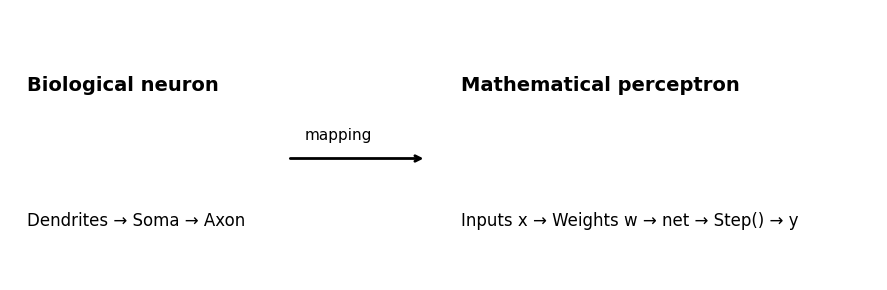

In [3]:
# (Optional) simple diagram for the report
plt.figure(figsize=(9, 3))
plt.axis('off')

plt.text(0.02, 0.7, 'Biological neuron', fontsize=14, weight='bold')
plt.text(0.02, 0.2, 'Dendrites → Soma → Axon', fontsize=12)

plt.text(0.52, 0.7, 'Mathematical perceptron', fontsize=14, weight='bold')
plt.text(0.52, 0.2, 'Inputs x → Weights w → net → Step() → y', fontsize=12)

plt.annotate('', xy=(0.48, 0.45), xytext=(0.32, 0.45), arrowprops=dict(arrowstyle='->', lw=2))
plt.text(0.34, 0.52, 'mapping', fontsize=11)

savefig('figures/partA_biological_mapping.png')
plt.show()


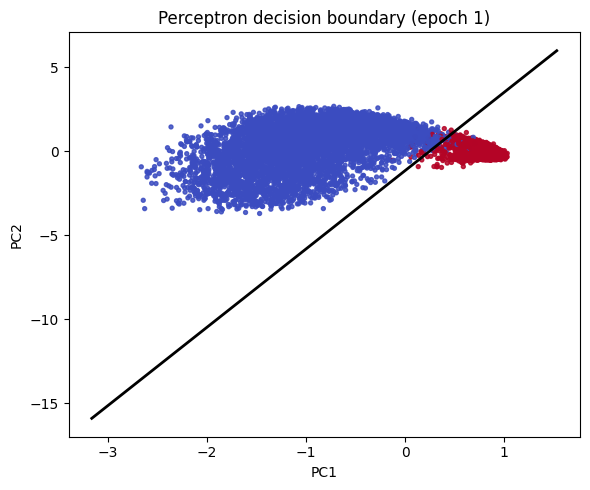

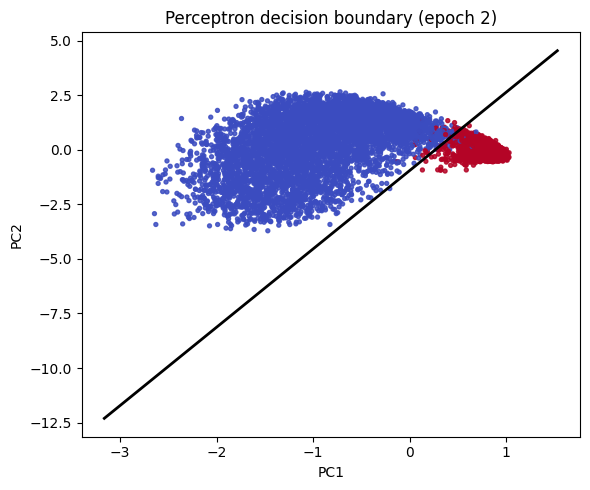

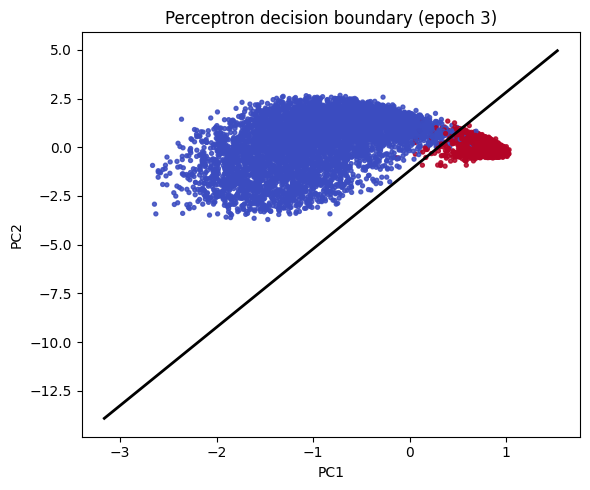

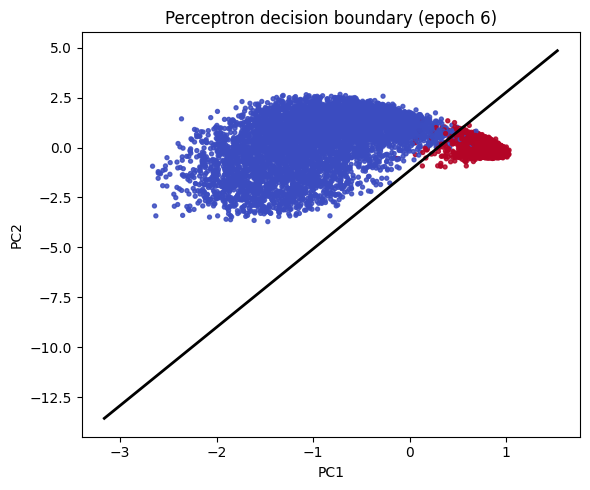

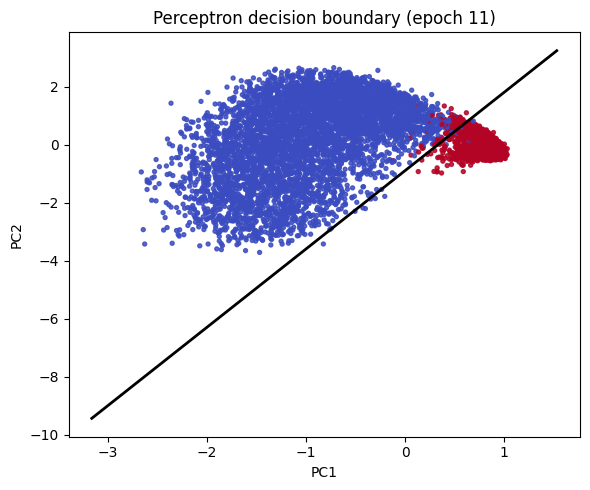

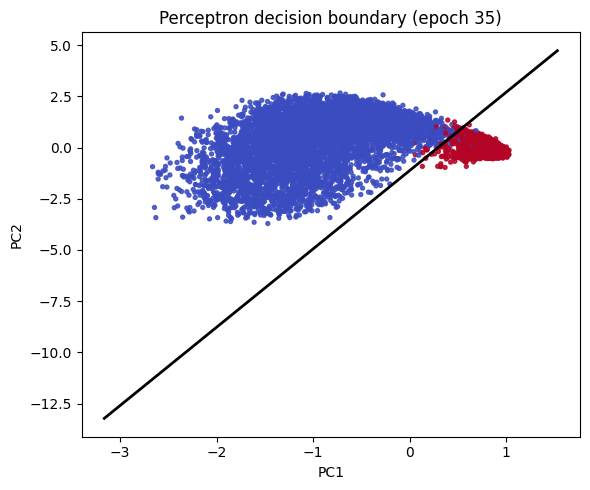

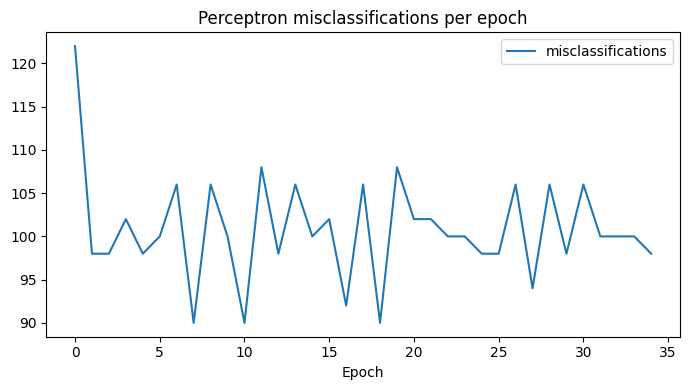

Test accuracy (0 vs 1 on PCA-2D): 0.9933806146572104


In [4]:
# A(ii) Perceptron on a binary MNIST subset (recommended: 0 vs 1)
DIGIT_A, DIGIT_B = 0, 1

x_bin_tr, y_bin_tr = mnist_binary_subset(x_tr, y_tr, DIGIT_A, DIGIT_B, max_samples=(4000 if FAST_RUN else None))
x_bin_te, y_bin_te = mnist_binary_subset(x_te, y_test, DIGIT_A, DIGIT_B, max_samples=(1000 if FAST_RUN else None))

# PCA to 2D for decision-boundary visualization
x2_tr, comps, mean = pca_2d(x_bin_tr)
x2_te = apply_pca(x_bin_te, comps, mean)

# Standardize 2D for stable boundaries
std2 = Standardizer.fit(x2_tr)
x2_tr_s = std2.transform(x2_tr)
x2_te_s = std2.transform(x2_te)

perc = Perceptron(lr=0.01, epochs=(20 if FAST_RUN else 35), seed=42).fit(x2_tr_s, y_bin_tr)

# Plot boundary evolution (every few epochs)
for epoch_i in [0, 1, 2, 5, 10, len(perc.history_['w'])-1]:
    w = perc.history_['w'][epoch_i]
    plot_decision_boundary_2d(
        x2_tr_s, y_bin_tr, w,
        title=f'Perceptron decision boundary (epoch {epoch_i+1})',
        path=f'figures/partA_perceptron_boundary_epoch_{epoch_i+1:02d}.png'
    )
    plt.show()

plot_curves({'misclassifications': perc.history_['miscls']}, 'Perceptron misclassifications per epoch',
            path='figures/partA_perceptron_miscls.png')
plt.show()

y_hat_te = perc.predict(x2_te_s)
print('Test accuracy (0 vs 1 on PCA-2D):', accuracy(y_bin_te, y_hat_te))


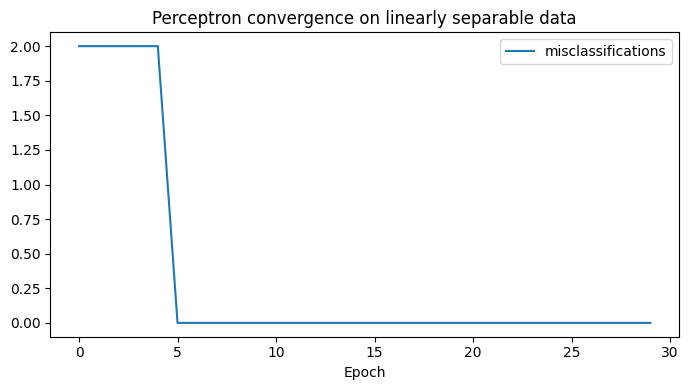

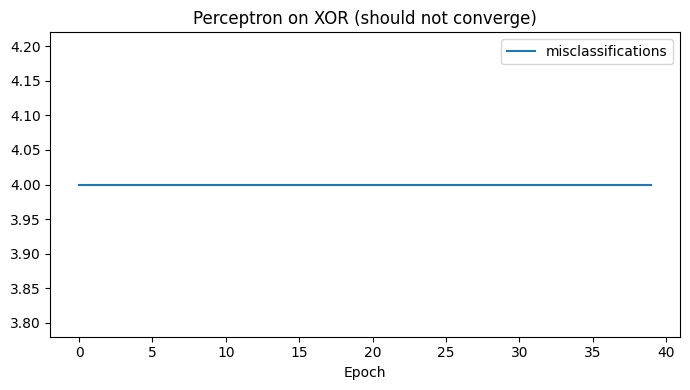

Final XOR predictions: [1 0 0 0] true: [0 1 1 0]


In [5]:
# A(iii) Convergence on linearly separable data + failure on XOR

# Linearly separable toy dataset
rng = np.random.default_rng(42)
N = 200
c0 = rng.normal(loc=[-1.2, -1.2], scale=0.5, size=(N, 2))
c1 = rng.normal(loc=[+1.2, +1.2], scale=0.5, size=(N, 2))
x_ls = np.vstack([c0, c1]).astype(np.float32)
y_ls = np.array([0]*N + [1]*N)

std = Standardizer.fit(x_ls)
x_ls = std.transform(x_ls)

perc_ls = Perceptron(lr=0.05, epochs=30, seed=1).fit(x_ls, y_ls)
plot_curves({'misclassifications': perc_ls.history_['miscls']}, 'Perceptron convergence on linearly separable data',
            path='figures/partA_perceptron_convergence_linearsep.png')
plt.show()

# XOR failure
x_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y_xor = np.array([0,1,1,0], dtype=int)
perc_xor = Perceptron(lr=0.2, epochs=40, seed=2).fit(x_xor, y_xor)
plot_curves({'misclassifications': perc_xor.history_['miscls']}, 'Perceptron on XOR (should not converge)',
            path='figures/partA_perceptron_xor_failure.png')
plt.show()

print('Final XOR predictions:', perc_xor.predict(x_xor), 'true:', y_xor)


## Part B — Delta Rule and Adaline

### B(i) Delta rule derivation (from MSE)

Define the Adaline linear output:

ŷ = sum_i w_i x_i + b

Mean squared error (MSE) objective:

E(w) = 1/2 · Σ(d − ŷ)^2

For one sample, ∂E/∂w_i = −(d − ŷ) x_i.

Gradient descent update:

w_i ← w_i − η ∂E/∂w_i = w_i + η (d − ŷ) x_i

So the **delta rule** is:

Δw_i = η (d − ŷ) x_i


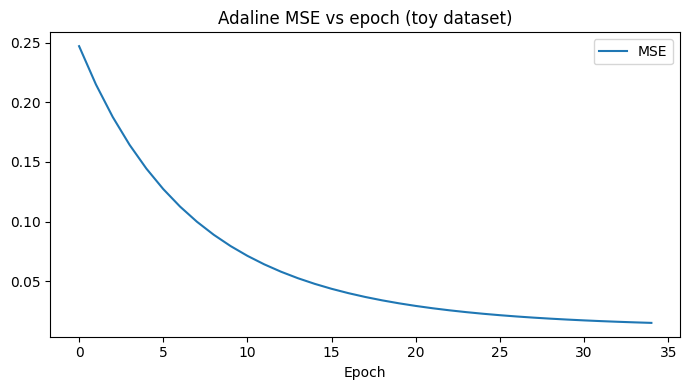

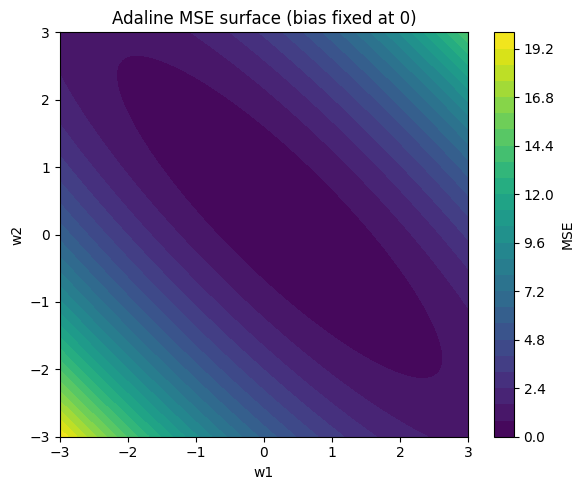

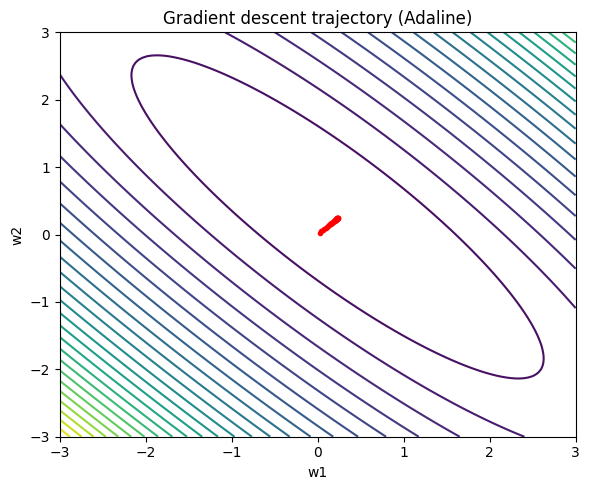

In [6]:
# B(ii) Adaline on a 2D toy dataset (loss surface + GD trajectory)

# Use the same linearly separable dataset, but Adaline optimizes MSE
x_toy = x_ls.copy()
y_toy = y_ls.astype(np.float32)

# Fit Adaline
adal = AdalineGD(lr=0.05, epochs=35, seed=0).fit(x_toy, y_toy)
plot_curves({'MSE': adal.history_['mse']}, 'Adaline MSE vs epoch (toy dataset)', path='figures/partB_adaline_mse_toy.png')
plt.show()

# MSE surface in weight space (visualize for 2D inputs, bias ignored in surface for simplicity)
W0, W1, Z = mse_loss_surface(x_toy, y_toy, w0_range=(-3, 3), w1_range=(-3, 3), grid=(80 if FAST_RUN else 120))
plt.figure(figsize=(6,5))
plt.contourf(W0, W1, Z, levels=30, cmap='viridis')
plt.colorbar(label='MSE')
plt.xlabel('w1')
plt.ylabel('w2')
plt.title('Adaline MSE surface (bias fixed at 0)')
savefig('figures/partB_adaline_mse_surface.png')
plt.show()

# Plot GD trajectory in (w1,w2)
traj = np.array([w[1:] for w in adal.history_['w']], dtype=np.float32)
plt.figure(figsize=(6,5))
plt.contour(W0, W1, Z, levels=25, cmap='viridis')
plt.plot(traj[:,0], traj[:,1], 'r-o', ms=3, lw=1)
plt.xlabel('w1')
plt.ylabel('w2')
plt.title('Gradient descent trajectory (Adaline)')
savefig('figures/partB_adaline_gd_trajectory.png')
plt.show()


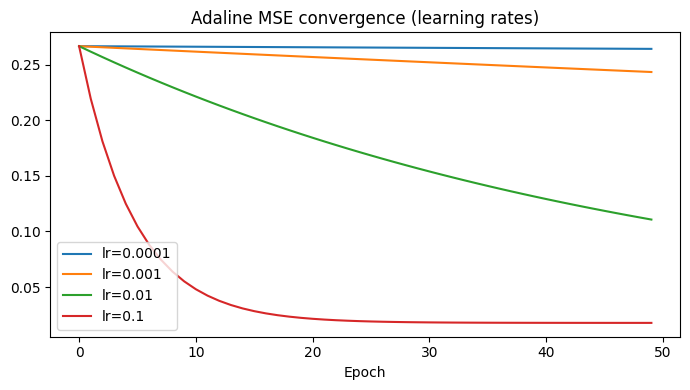

In [7]:
# B(iii) Learning rate analysis on MNIST (binary 0 vs 1)

lrs = [0.0001, 0.001, 0.01, 0.1]
curves = {}

# Use PCA-2D again for clean plots + quick runtime
x_lr = x2_tr_s
y_lr = y_bin_tr.astype(np.float32)

for lr in lrs:
    model = AdalineGD(lr=lr, epochs=(20 if FAST_RUN else 50), seed=0).fit(x_lr, y_lr)
    curves[f'lr={lr}'] = model.history_['mse']

plot_curves(curves, 'Adaline MSE convergence (learning rates)', path='figures/partB_adaline_lr_comparison.png')
plt.show()


## Part C — Kohonen Self-Organizing Map (SOM)

SOM maps high-dimensional inputs to a 2D neuron grid while preserving topology.

- **BMU selection:** BMU = argmin_i ||x − w_i||
- **Neighborhood (Gaussian):** h_i(t)=exp(−||r_i−r_BMU||^2 / (2σ(t)^2))
- **Decay:** η(t)=η0 exp(−t/λ), σ(t)=σ0 exp(−t/λ)
- **Update:** w_i ← w_i + η(t) h_i(t) (x − w_i)


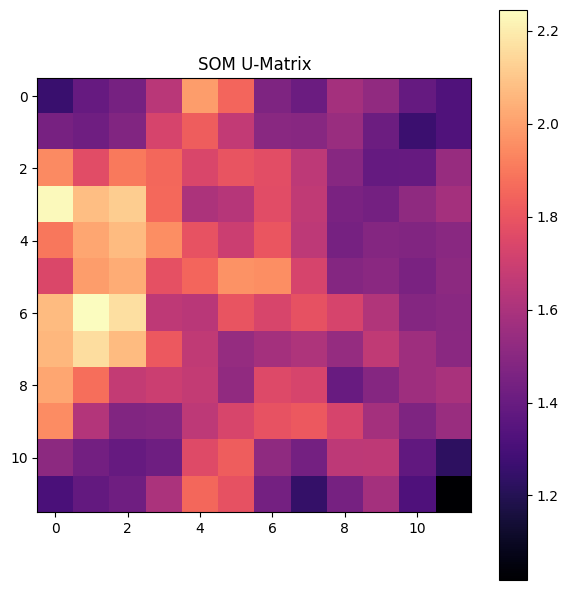

Quantization Error (QE): 5.535064220428467
Topographic Error (TE) : 0.10775


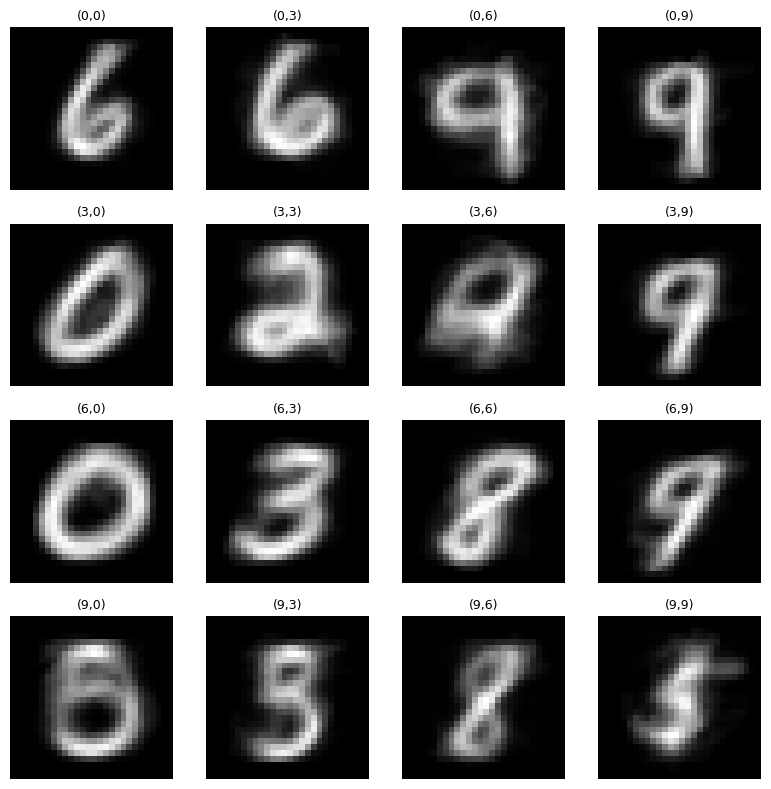

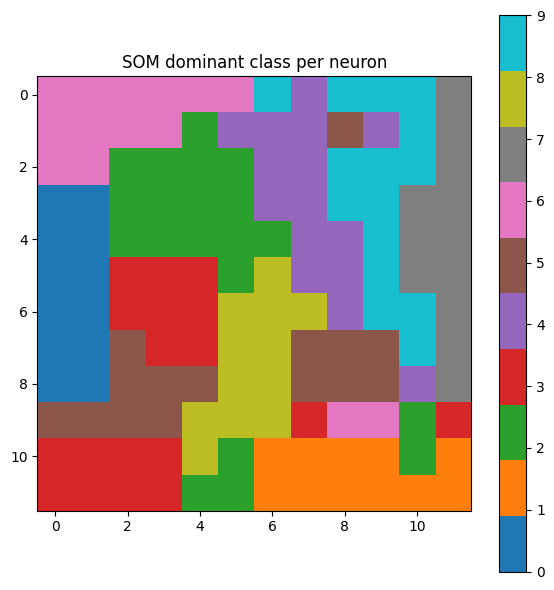

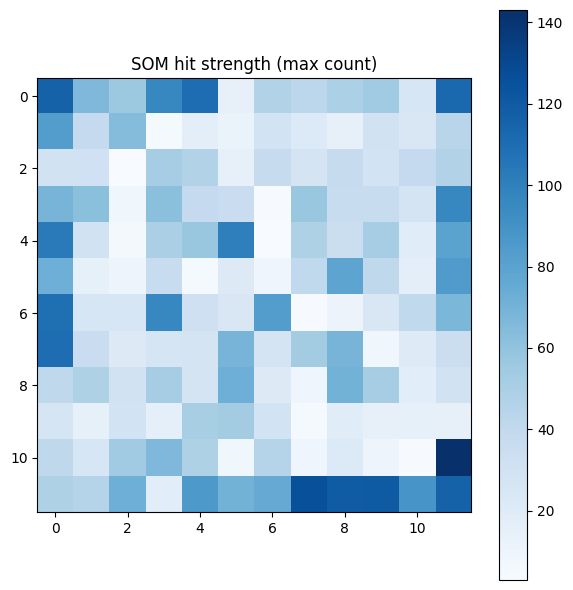

In [8]:
# C(ii)-(iii) Train SOM on MNIST subset + visualize

# Use raw [0,1] pixels for SOM (not standardized)
x_train_raw, y_train_raw, _, _ = load_mnist(flatten=True)

# SOM is expensive; these defaults are tuned for Colab runtime.
n_som = 4000 if FAST_RUN else 8000
x_som = x_train_raw[:n_som].astype(np.float32)
y_som = y_train_raw[:n_som].astype(int)

epochs = 3 if FAST_RUN else 6
som = SOM(grid_h=12, grid_w=12, input_dim=784, lr0=0.5, sigma0=6.0, epochs=epochs, seed=42)
som.fit(x_som)

umat = som.u_matrix()
plt.figure(figsize=(6,6))
plt.imshow(umat, cmap='magma')
plt.title('SOM U-Matrix')
plt.colorbar()
savefig('figures/partC_som_umatrix.png')
plt.show()

qe = som.quantization_error(x_som)
te = som.topographic_error(x_som)
print('Quantization Error (QE):', qe)
print('Topographic Error (TE) :', te)

# Weight maps: visualize a few neuron prototypes
W = som.weights  # (H,W,784)
assert W is not None
plt.figure(figsize=(8,8))
for i in range(16):
    r = (i // 4) * 3
    c = (i % 4) * 3
    proto = W[r, c].reshape(28,28)
    plt.subplot(4,4,i+1)
    plt.imshow(proto, cmap='gray')
    plt.axis('off')
    plt.title(f'({r},{c})', fontsize=9)
savefig('figures/partC_som_weight_maps.png')
plt.show()

# Class hit map (which digits activate which neurons)
bmus = som.bmu_batch(x_som)  # (N,2)
hits = np.zeros((som.grid_h, som.grid_w, 10), dtype=np.int32)
for (r,c), lab in zip(bmus, y_som):
    hits[r, c, lab] += 1

# Plot dominant class per neuron
winner = hits.argmax(axis=2)
strength = hits.max(axis=2)
plt.figure(figsize=(6,6))
plt.imshow(winner, cmap='tab10')
plt.title('SOM dominant class per neuron')
plt.colorbar()
savefig('figures/partC_som_class_hitmap_winner.png')
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(strength, cmap='Blues')
plt.title('SOM hit strength (max count)')
plt.colorbar()
savefig('figures/partC_som_class_hitmap_strength.png')
plt.show()


Threshold (95th percentile clean): 7.48167610168457
Precision: 0.8298755186721986 Recall: 0.999999999999999 F1: 0.9070294784575534


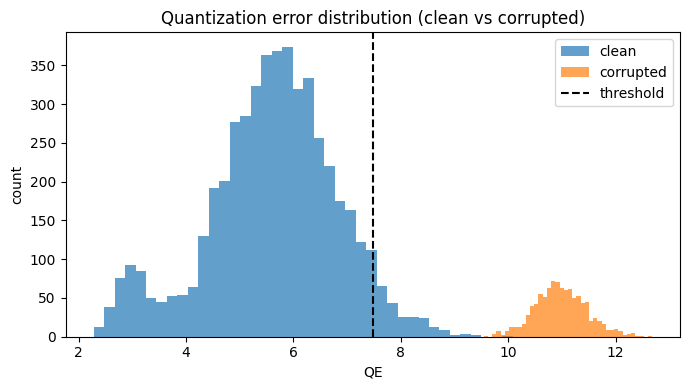

In [9]:
# C(iv) Anomaly detection using per-sample quantization error (QE)

# Create synthetic anomalies by corrupting some samples (salt noise)
rng = np.random.default_rng(123)

n_eval = 2000 if FAST_RUN else 5000
x_eval = x_train_raw[n_som:n_som+n_eval].astype(np.float32)

# Copy and corrupt 20% as anomalies
is_anom = np.zeros((x_eval.shape[0],), dtype=int)
idx_anom = rng.choice(x_eval.shape[0], size=int(0.2 * x_eval.shape[0]), replace=False)
is_anom[idx_anom] = 1

x_cor = x_eval.copy()
noise = rng.random(x_cor.shape).astype(np.float32)
flip = (noise < 0.15).astype(np.float32)
x_cor[idx_anom] = np.clip(x_cor[idx_anom] * (1 - flip[idx_anom]) + flip[idx_anom] * (1 - x_cor[idx_anom]), 0, 1)

qe_scores = som.quantization_error_per_sample(x_cor)

# Threshold at 95th percentile of *clean* scores
qe_clean = som.quantization_error_per_sample(x_eval)
thr = float(np.percentile(qe_clean, 95))
y_pred_anom = (qe_scores > thr).astype(int)

prec, rec, f1 = precision_recall_f1(is_anom, y_pred_anom)
print('Threshold (95th percentile clean):', thr)
print('Precision:', prec, 'Recall:', rec, 'F1:', f1)

plt.figure(figsize=(7,4))
plt.hist(qe_clean, bins=40, alpha=0.7, label='clean')
plt.hist(qe_scores[idx_anom], bins=40, alpha=0.7, label='corrupted')
plt.axvline(thr, color='k', ls='--', label='threshold')
plt.title('Quantization error distribution (clean vs corrupted)')
plt.xlabel('QE')
plt.ylabel('count')
plt.legend()
savefig('figures/partC_som_anomaly_qe_hist.png')
plt.show()


## Part D — Backpropagation Network (MLP)

### D(i) Backpropagation equations (3-layer MLP)

For neuron k in the output layer:

δ_k = (d_k − y_k) · f'(net_k)

For neuron j in a hidden layer:

δ_j = f'(net_j) · Σ_k δ_k · w_kj

General weight update:

Δw_ij = η · δ_j · o_i

In practice, with **softmax + cross-entropy**, the output-layer gradient simplifies to (p − y).


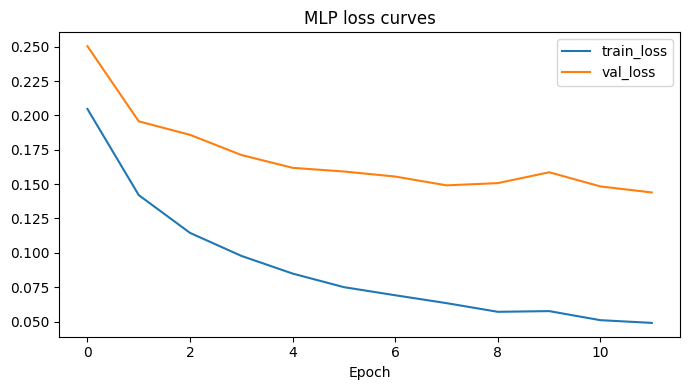

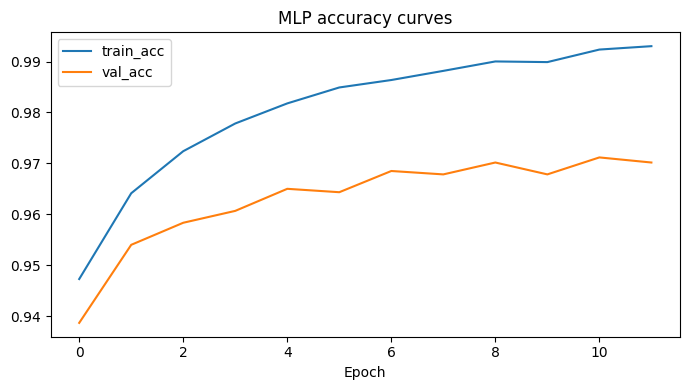

Test accuracy: 0.9714


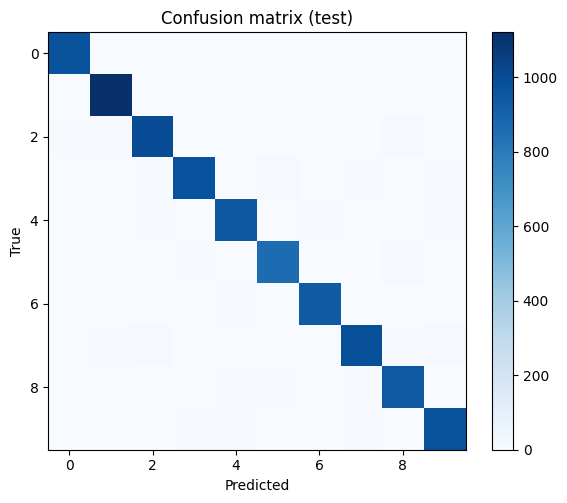

In [10]:
# D(ii) Train baseline MLP (784→128→64→10) in NumPy

# Optionally reduce dataset for demo
if FAST_RUN:
    n_tr = 12000
    n_val = 2000
    x_tr_use, y_tr_use = x_tr[:n_tr], y_tr[:n_tr]
    x_val_use, y_val_use = x_val[:n_val], y_val[:n_val]
else:
    x_tr_use, y_tr_use = x_tr, y_tr
    x_val_use, y_val_use = x_val, y_val

mlp = MLP(
    input_dim=x_tr_use.shape[1],
    h1=128,
    h2=64,
    activation='relu',
    lr=0.01,
    epochs=(6 if FAST_RUN else 12),
    batch_size=128,
    momentum=0.9,
    l2=1e-4,
    dropout=0.1,
    seed=42,
)
mlp.fit(x_tr_use, y_tr_use, x_val_use, y_val_use)

# Curves
plot_curves(
    {'train_loss': mlp.history_['train_loss'], 'val_loss': mlp.history_['val_loss']},
    'MLP loss curves',
    path='figures/partD_mlp_loss_curves.png'
)
plt.show()

plot_curves(
    {'train_acc': mlp.history_['train_acc'], 'val_acc': mlp.history_['val_acc']},
    'MLP accuracy curves',
    path='figures/partD_mlp_accuracy_curves.png'
)
plt.show()

# Test evaluation
if FAST_RUN:
    x_te_use, y_te_use = x_te[:3000], y_test[:3000]
else:
    x_te_use, y_te_use = x_te, y_test

y_hat = mlp.predict(x_te_use)
acc = accuracy(y_te_use, y_hat)
print('Test accuracy:', acc)

cm = confusion_matrix(y_te_use, y_hat, num_classes=10)
plot_confusion_matrix(cm, 'Confusion matrix (test)', path='figures/partD_confusion_matrix.png')
plt.show()


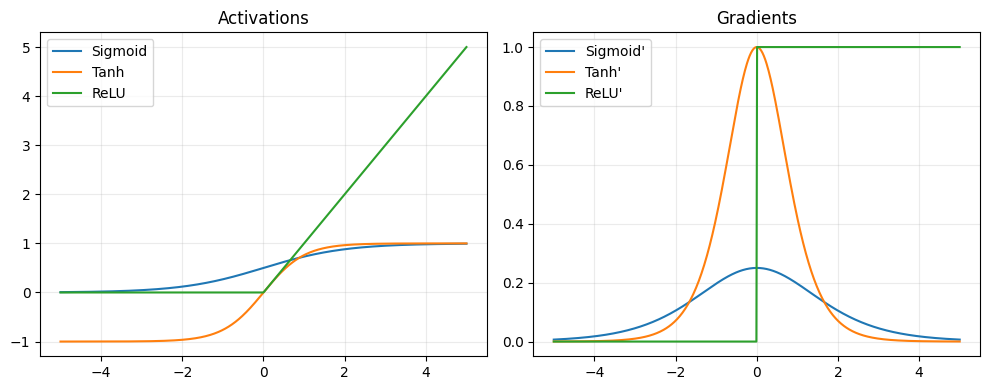

/content/src/mlp.py:30: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


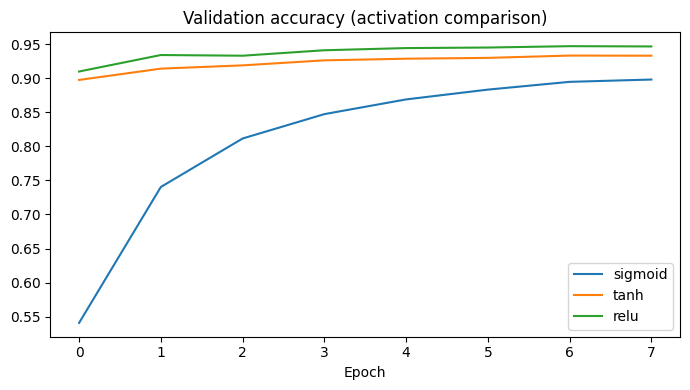

In [11]:
# D(iii) Activation function comparison (Sigmoid vs Tanh vs ReLU)

plot_activation_curves(path='figures/partD_activation_curves_and_gradients.png')
plt.show()

acts = ['sigmoid', 'tanh', 'relu']
results = {}

# Use a smaller training budget for fair comparison
n_tr = 8000 if FAST_RUN else 15000
n_val = 2000 if FAST_RUN else 5000
x_tr_c, y_tr_c = x_tr[:n_tr], y_tr[:n_tr]
x_val_c, y_val_c = x_val[:n_val], y_val[:n_val]

for act in acts:
    model = MLP(
        input_dim=x_tr_c.shape[1], h1=128, h2=64, activation=act,
        lr=0.01, epochs=(4 if FAST_RUN else 8), batch_size=128,
        momentum=0.9, l2=1e-4, dropout=0.0, seed=42
    )
    model.fit(x_tr_c, y_tr_c, x_val_c, y_val_c)
    results[act] = model.history_['val_acc']

plot_curves(results, 'Validation accuracy (activation comparison)', path='figures/partD_activation_comparison_val_acc.png')
plt.show()


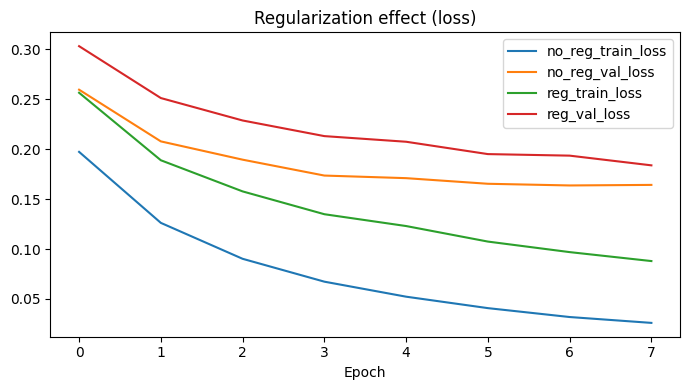

In [12]:
# D(iv) Regularization: compare no-reg vs L2+Dropout

n_tr = 12000 if FAST_RUN else 30000
n_val = 3000 if FAST_RUN else 8000
x_tr_r, y_tr_r = x_tr[:n_tr], y_tr[:n_tr]
x_val_r, y_val_r = x_val[:n_val], y_val[:n_val]

no_reg = MLP(
    input_dim=x_tr_r.shape[1], h1=128, h2=64, activation='relu',
    lr=0.01, epochs=(4 if FAST_RUN else 8), batch_size=128,
    momentum=0.9, l2=0.0, dropout=0.0, seed=1
).fit(x_tr_r, y_tr_r, x_val_r, y_val_r)

reg = MLP(
    input_dim=x_tr_r.shape[1], h1=128, h2=64, activation='relu',
    lr=0.01, epochs=(4 if FAST_RUN else 8), batch_size=128,
    momentum=0.9, l2=1e-4, dropout=0.2, seed=1
).fit(x_tr_r, y_tr_r, x_val_r, y_val_r)

plot_curves(
    {
        'no_reg_train_loss': no_reg.history_['train_loss'],
        'no_reg_val_loss': no_reg.history_['val_loss'],
        'reg_train_loss': reg.history_['train_loss'],
        'reg_val_loss': reg.history_['val_loss'],
    },
    'Regularization effect (loss)',
    path='figures/partD_regularization_loss.png'
)
plt.show()


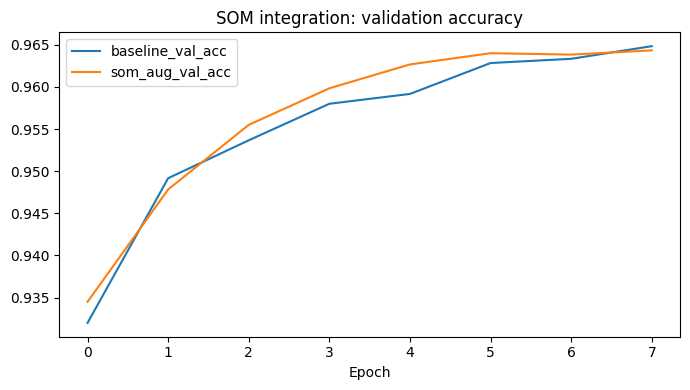

Baseline final val acc: 0.9648333333333333
SOM-aug final val acc: 0.9643333333333334


In [13]:
# D(v) SOM integration: add SOM BMU coordinates as auxiliary features

# Convert BMU coords to 2 normalized features (row/grid_h, col/grid_w)

def som_features(som, x):
    b = som.bmu_batch(x.astype(np.float32))
    f = np.zeros((b.shape[0], 2), dtype=np.float32)
    f[:,0] = b[:,0] / max(1, (som.grid_h - 1))
    f[:,1] = b[:,1] / max(1, (som.grid_w - 1))
    return f

# Use a medium training subset for fair comparison
n_tr = 15000 if FAST_RUN else 40000
n_val = 3000 if FAST_RUN else 8000

# MLP uses standardized features
x_tr_si, y_tr_si = x_tr[:n_tr], y_tr[:n_tr]
x_val_si, y_val_si = x_val[:n_val], y_val[:n_val]

# SOM features MUST come from the *matching raw examples* (aligned via indices in the load cell)
f_tr = som_features(som, x_tr_raw[:n_tr])
f_val = som_features(som, x_val_raw[:n_val])

x_tr_aug = np.concatenate([x_tr_si, f_tr], axis=1)
x_val_aug = np.concatenate([x_val_si, f_val], axis=1)

baseline = MLP(
    input_dim=x_tr_si.shape[1], h1=128, h2=64, activation='relu',
    lr=0.01, epochs=(4 if FAST_RUN else 8), batch_size=128,
    momentum=0.9, l2=1e-4, dropout=0.1, seed=7
).fit(x_tr_si, y_tr_si, x_val_si, y_val_si)

augmented = MLP(
    input_dim=x_tr_aug.shape[1], h1=128, h2=64, activation='relu',
    lr=0.01, epochs=(4 if FAST_RUN else 8), batch_size=128,
    momentum=0.9, l2=1e-4, dropout=0.1, seed=7
).fit(x_tr_aug, y_tr_si, x_val_aug, y_val_si)

plot_curves(
    {'baseline_val_acc': baseline.history_['val_acc'], 'som_aug_val_acc': augmented.history_['val_acc']},
    'SOM integration: validation accuracy',
    path='figures/partD_som_integration_val_acc.png'
)
plt.show()

print('Baseline final val acc:', baseline.history_['val_acc'][-1])
print('SOM-aug final val acc:', augmented.history_['val_acc'][-1])


## Results summary (fill into report)

After running once, use the saved figures in `figures/` inside your report.

**What to include:**
- Perceptron: misclassifications vs epoch + boundary evolution (PCA-2D)
- Adaline: MSE surface + GD trajectory + learning-rate comparison
- SOM: U-matrix + weight maps + hit maps + QE/TE + anomaly precision/recall
- MLP: loss/accuracy curves + confusion matrix + activation comparison + regularization + SOM integration


## Export / Download

This section bundles all generated figures into a single ZIP for download.


In [14]:
import os, shutil
from pathlib import Path

# Zip all figures
fig_dir = Path('figures')
if not fig_dir.exists():
    raise FileNotFoundError('figures/ folder not found. Run the training cells first.')

zip_name = 'ccp_figures.zip'
# make_archive wants base name without .zip
base = zip_name[:-4]
if Path(zip_name).exists():
    Path(zip_name).unlink()
shutil.make_archive(base, 'zip', fig_dir)
print('Created:', Path(zip_name).resolve())

# If running in Google Colab, trigger browser download
try:
    from google.colab import files  # type: ignore
    files.download(zip_name)
except Exception as e:
    print('Auto-download not available in this environment.')
    print('Download the ZIP from the file explorer:', zip_name)


Created: /content/ccp_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Upload Figures to Google Drive

If you are running on a Colab runtime, this will mount Google Drive and copy `ccp_figures.zip` (and optionally the full `figures/` folder).


In [16]:
from pathlib import Path
import shutil

# Mount Drive (Colab)
from google.colab import drive  # type: ignore

drive.mount('/content/drive')

src_zip = Path('/content/ccp_figures.zip')
if not src_zip.exists():
    raise FileNotFoundError('Missing /content/ccp_figures.zip. Run the export cell first.')

dst_dir = Path('/content/drive/MyDrive/CCP_ANN_Submission')
dst_dir.mkdir(parents=True, exist_ok=True)

shutil.copy2(src_zip, dst_dir / src_zip.name)
print('Copied ZIP to:', (dst_dir / src_zip.name))

# Optional: also copy the whole figures folder
src_fig = Path('/content/figures')
if src_fig.exists():
    dst_fig = dst_dir / 'figures'
    if dst_fig.exists():
        shutil.rmtree(dst_fig)
    shutil.copytree(src_fig, dst_fig)
    print('Copied figures/ to:', dst_fig)


Mounted at /content/drive
Copied ZIP to: /content/drive/MyDrive/CCP_ANN_Submission/ccp_figures.zip
Copied figures/ to: /content/drive/MyDrive/CCP_ANN_Submission/figures
